<a href="https://colab.research.google.com/github/Prameela-04/podcast-engagement-analytics/blob/main/02_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELL 1: Load libraries and connect to Google Drive
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive — files persist here permanently
from google.colab import drive
drive.mount('/content/drive')

# Path to your project folder
project_path = '/content/drive/MyDrive/podcast_analytics'

# Load cleaned dataset directly from Drive
df = pd.read_csv(f'{project_path}/USvideos_cleaned.csv')

# Set professional visual style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi']        = 130
plt.rcParams['figure.facecolor']  = 'white'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Source: Google Drive (permanent)")
print(f"Ready for analysis.")

Mounted at /content/drive
Dataset loaded: 6,351 rows x 30 columns
Source: Google Drive (permanent)
Ready for analysis.


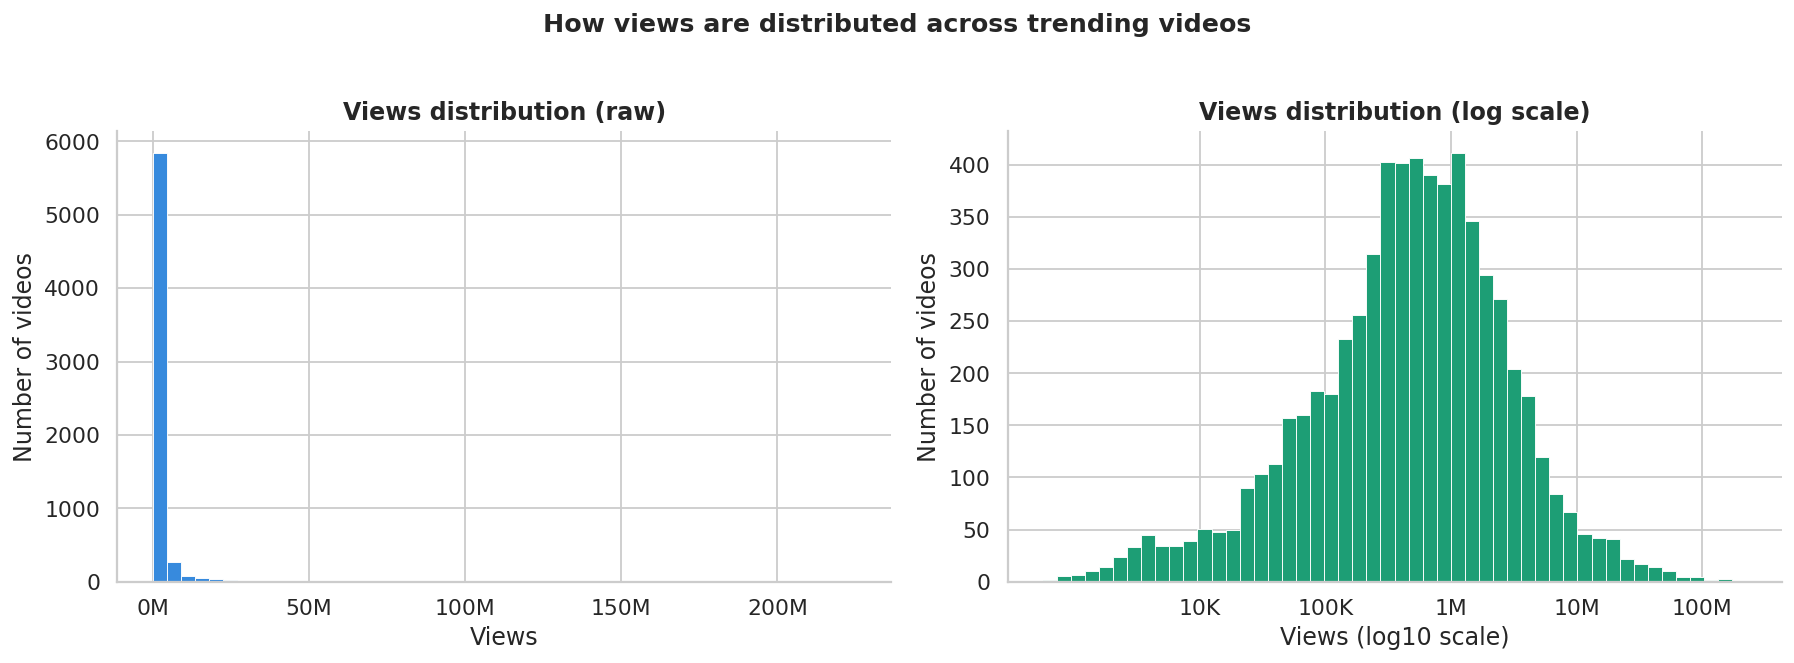

INSIGHT:
  Most videos cluster between 0.2M – 1.5M views
  Median: 0.52M views
  Mean:   1.96M views  (pulled up by outliers)
  Skew:   14.15  (above 1.0 = heavily right-skewed)


In [ ]:
# ============================================================
# CELL 2: Views distribution — normal vs log scale
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left chart: raw distribution ---
axes[0].hist(df['views'], bins=50, color='#378ADD', edgecolor='white', linewidth=0.5)
axes[0].set_title('Views distribution (raw)', fontweight='bold')
axes[0].set_xlabel('Views')
axes[0].set_ylabel('Number of videos')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# --- Right chart: log scale (the analyst's view) ---
axes[1].hist(np.log10(df['views'] + 1), bins=50,
             color='#1D9E75', edgecolor='white', linewidth=0.5)
axes[1].set_title('Views distribution (log scale)', fontweight='bold')
axes[1].set_xlabel('Views (log10 scale)')
axes[1].set_ylabel('Number of videos')
axes[1].set_xticks([4, 5, 6, 7, 8])
axes[1].set_xticklabels(['10K', '100K', '1M', '10M', '100M'])

plt.suptitle('How views are distributed across trending videos',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_01_views_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

# Print the insight
print("INSIGHT:")
print(f"  Most videos cluster between "
      f"{df['views'].quantile(0.25)/1e6:.1f}M – "
      f"{df['views'].quantile(0.75)/1e6:.1f}M views")
print(f"  Median: {df['views'].median()/1e6:.2f}M views")
print(f"  Mean:   {df['views'].mean()/1e6:.2f}M views  "
      f"(pulled up by outliers)")
print(f"  Skew:   {df['views'].skew():.2f}  "
      f"(above 1.0 = heavily right-skewed)")

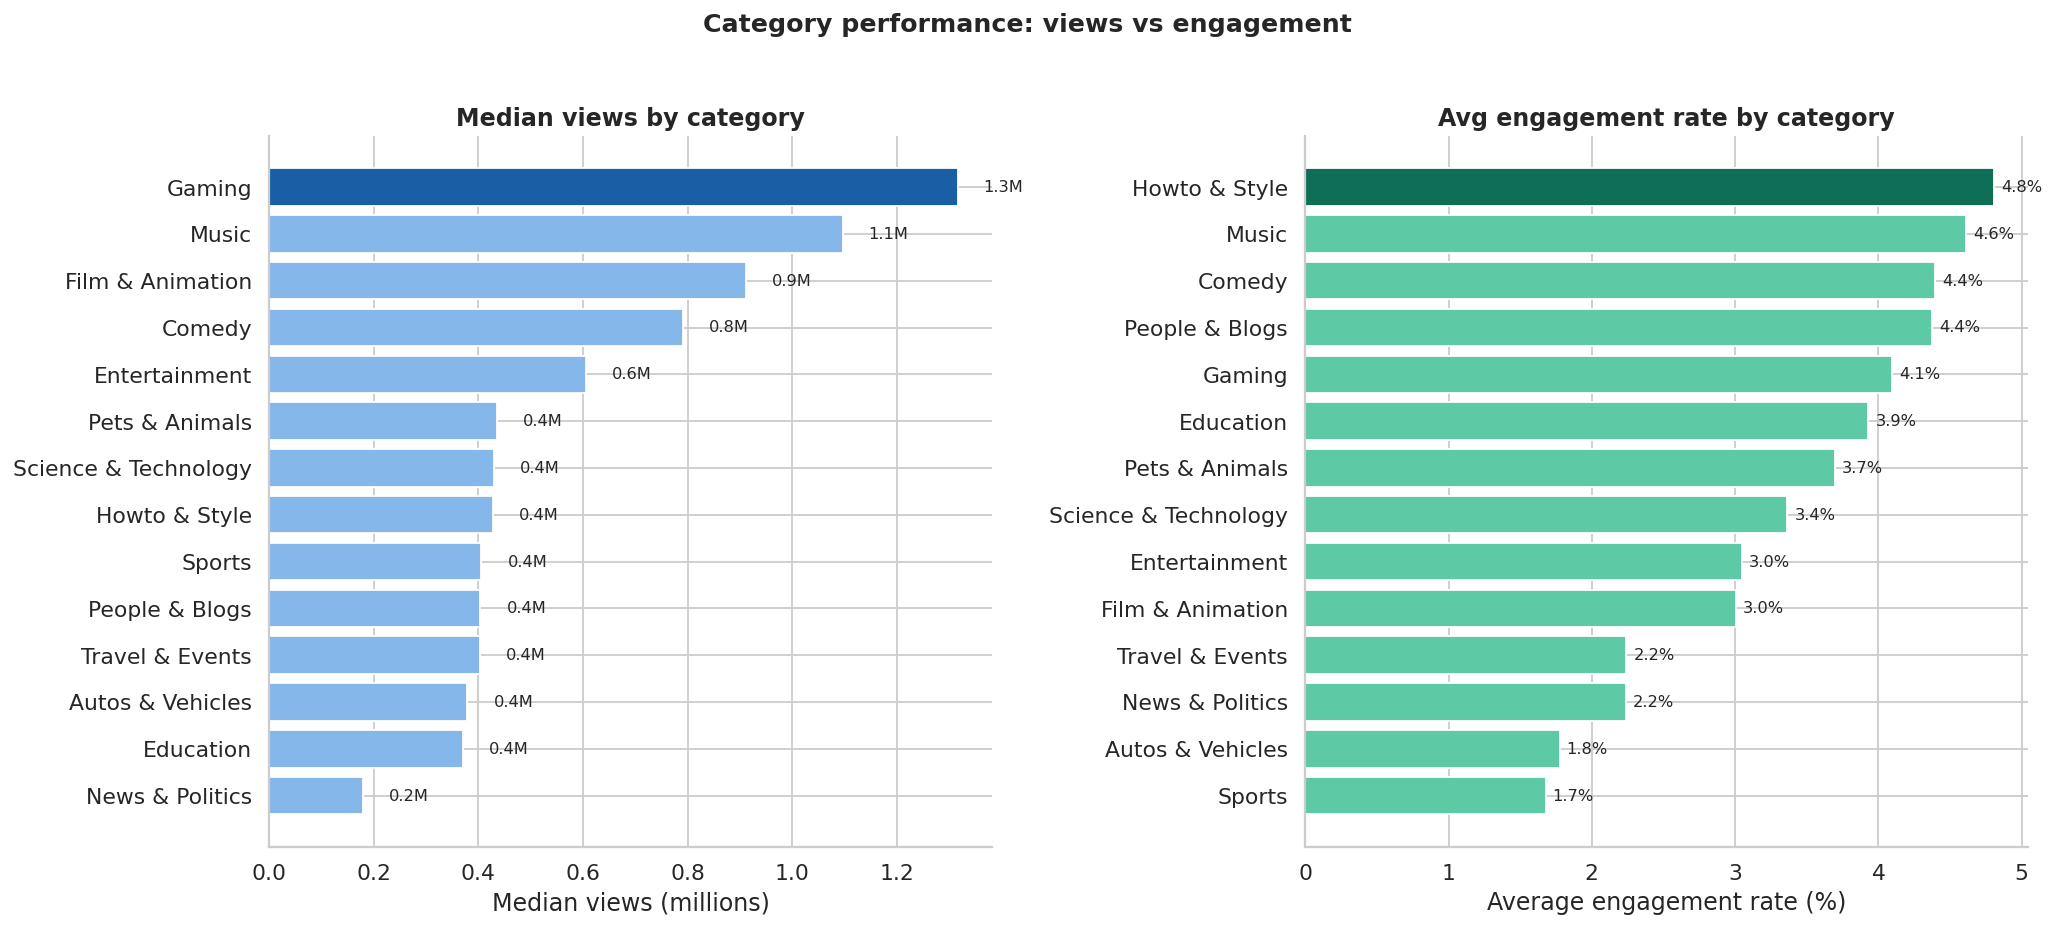


CATEGORY INSIGHTS:
       category_name  video_count  median_views  avg_engagement
              Gaming          103     1316002.0        4.095061
               Music          801     1096158.0        4.608787
    Film & Animation          320      910969.5        3.005100
              Comedy          544      790545.5        4.396297
       Entertainment         1621      606048.0        3.048845
      Pets & Animals          140      434946.0        3.696423
Science & Technology          381      429830.0        3.365419
       Howto & Style          594      426985.0        4.804008
              Sports          449      405781.0        1.676942
      People & Blogs          495      403844.0        4.376055
     Travel & Events           59      402402.0        2.242008
    Autos & Vehicles           71      378901.0        1.774941
           Education          251      370450.0        3.930328
     News & Politics          504      178852.0        2.237424


In [ ]:
# ============================================================
# CELL 3: Which categories dominate on views vs engagement?
# ============================================================

# Aggregate by category
cat_stats = df.groupby('category_name').agg(
    video_count    = ('video_id',        'count'),
    median_views   = ('views',           'median'),
    median_likes   = ('likes',           'median'),
    avg_engagement = ('engagement_rate', 'mean'),
    avg_like_rate  = ('like_rate',       'mean')
).reset_index().sort_values('median_views', ascending=False)

# Remove tiny categories (under 20 videos — not statistically meaningful)
cat_stats = cat_stats[cat_stats['video_count'] >= 20]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Left: median views by category ---
colors_views = ['#185FA5' if i == 0 else '#85B7EB'
                for i in range(len(cat_stats))]
bars = axes[0].barh(cat_stats['category_name'],
                    cat_stats['median_views'] / 1e6,
                    color=colors_views, edgecolor='white')
axes[0].set_xlabel('Median views (millions)')
axes[0].set_title('Median views by category', fontweight='bold')
axes[0].invert_yaxis()
for bar, val in zip(bars, cat_stats['median_views']):
    axes[0].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val/1e6:.1f}M', va='center', fontsize=9)

# --- Right: avg engagement rate by category ---
cat_eng = cat_stats.sort_values('avg_engagement', ascending=False)
colors_eng = ['#0F6E56' if i == 0 else '#5DCAA5'
              for i in range(len(cat_eng))]
bars2 = axes[1].barh(cat_eng['category_name'],
                     cat_eng['avg_engagement'],
                     color=colors_eng, edgecolor='white')
axes[1].set_xlabel('Average engagement rate (%)')
axes[1].set_title('Avg engagement rate by category', fontweight='bold')
axes[1].invert_yaxis()
for bar, val in zip(bars2, cat_eng['avg_engagement']):
    axes[1].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)

plt.suptitle('Category performance: views vs engagement',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_02_category_performance.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nCATEGORY INSIGHTS:")
print(cat_stats[['category_name', 'video_count',
                  'median_views', 'avg_engagement']].to_string(index=False))

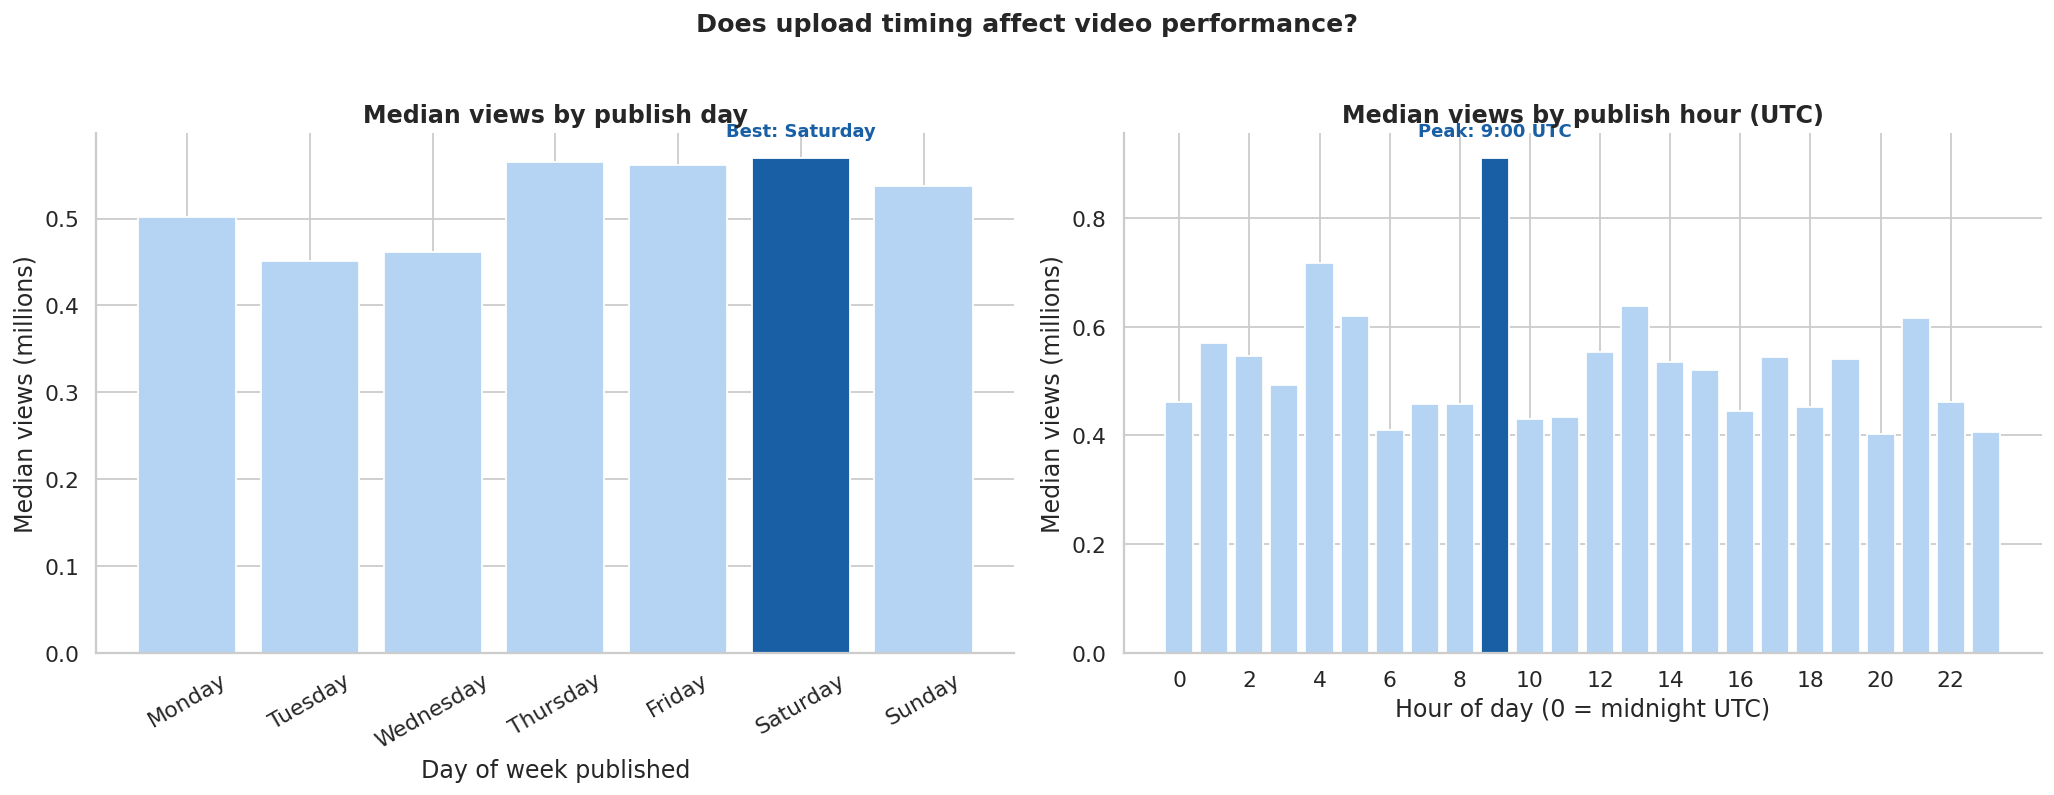


TIMING INSIGHTS:
  Best day to publish:  Saturday
  Peak hour (UTC):      9:00
  Worst day median:     0.45M views
  Best day median:      0.57M views
  Timing advantage:     1.3x


In [ ]:
# ============================================================
# CELL 4: When do high-performing videos get published?
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Define consistent day order
day_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']

# --- Left: median views by day of week ---
day_perf = (df.groupby('publish_day_of_week')['views']
              .median()
              .reindex(day_order)
              .reset_index())

bar_colors = ['#185FA5' if v == day_perf['views'].max()
              else '#B5D4F4' for v in day_perf['views']]

axes[0].bar(day_perf['publish_day_of_week'],
            day_perf['views'] / 1e6,
            color=bar_colors, edgecolor='white')
axes[0].set_title('Median views by publish day', fontweight='bold')
axes[0].set_xlabel('Day of week published')
axes[0].set_ylabel('Median views (millions)')
axes[0].tick_params(axis='x', rotation=30)

# Annotate best day
best_day = day_perf.loc[day_perf['views'].idxmax(), 'publish_day_of_week']
axes[0].annotate(f'Best: {best_day}',
                 xy=(day_perf['publish_day_of_week'].tolist().index(best_day),
                     day_perf['views'].max()/1e6),
                 xytext=(0, 12), textcoords='offset points',
                 ha='center', fontsize=10, color='#185FA5', fontweight='bold')

# --- Right: median views by publish hour ---
hour_perf = (df.groupby('publish_hour')['views']
               .median()
               .reset_index())

peak_hour = hour_perf.loc[hour_perf['views'].idxmax(), 'publish_hour']
hour_colors = ['#185FA5' if h == peak_hour else '#B5D4F4'
               for h in hour_perf['publish_hour']]

axes[1].bar(hour_perf['publish_hour'],
            hour_perf['views'] / 1e6,
            color=hour_colors, edgecolor='white', width=0.8)
axes[1].set_title('Median views by publish hour (UTC)', fontweight='bold')
axes[1].set_xlabel('Hour of day (0 = midnight UTC)')
axes[1].set_ylabel('Median views (millions)')
axes[1].set_xticks(range(0, 24, 2))

axes[1].annotate(f'Peak: {peak_hour}:00 UTC',
                 xy=(peak_hour, hour_perf['views'].max()/1e6),
                 xytext=(0, 12), textcoords='offset points',
                 ha='center', fontsize=10, color='#185FA5', fontweight='bold')

plt.suptitle('Does upload timing affect video performance?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_03_upload_timing.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\nTIMING INSIGHTS:")
print(f"  Best day to publish:  {best_day}")
print(f"  Peak hour (UTC):      {peak_hour}:00")
print(f"  Worst day median:     "
      f"{day_perf['views'].min()/1e6:.2f}M views")
print(f"  Best day median:      "
      f"{day_perf['views'].max()/1e6:.2f}M views")
print(f"  Timing advantage:     "
      f"{day_perf['views'].max()/day_perf['views'].min():.1f}x")

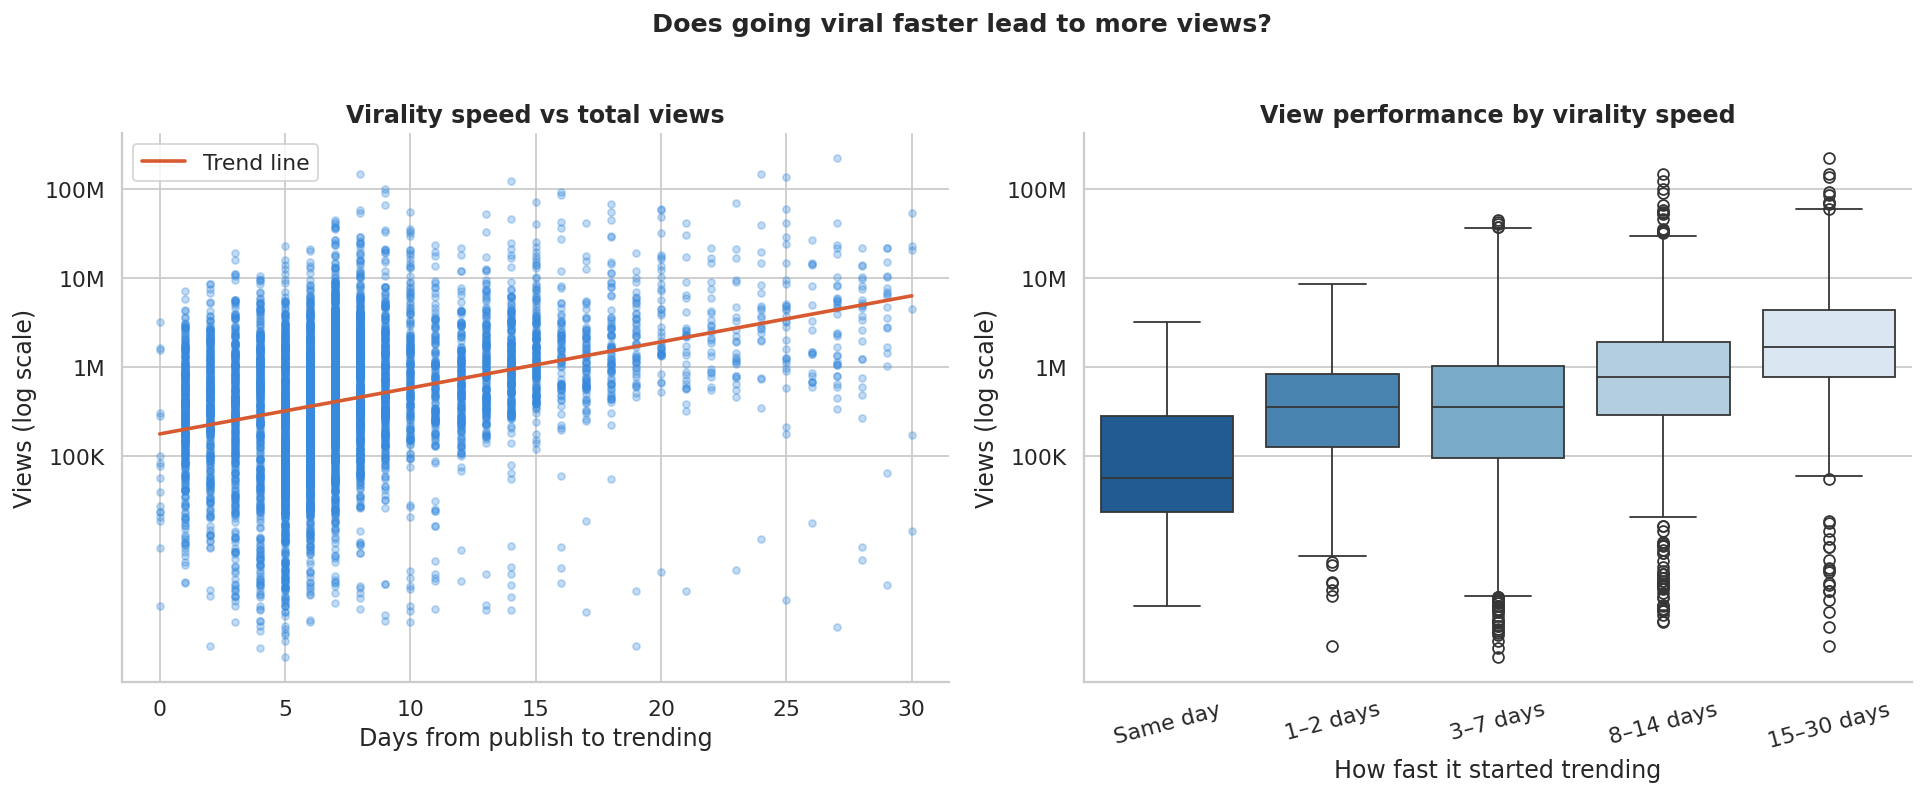


VIRALITY INSIGHTS:
  Correlation (days to trend vs log views): 0.345
  Interpretation: Speed of trending does not strongly predict views


In [ ]:
# ============================================================
# CELL 5: Virality speed — does trending faster mean more views?
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Filter to sensible range (cap at 30 days)
df_trend = df[df['days_to_trend'] <= 30].copy()

# --- Left: scatter — days to trend vs views ---
axes[0].scatter(df_trend['days_to_trend'],
                np.log10(df_trend['views'] + 1),
                alpha=0.3, s=15, color='#378ADD')

# Add trend line
z = np.polyfit(df_trend['days_to_trend'],
               np.log10(df_trend['views'] + 1), 1)
p = np.poly1d(z)
x_line = np.linspace(0, 30, 100)
axes[0].plot(x_line, p(x_line), color='#D85A30',
             linewidth=2, label='Trend line')

axes[0].set_xlabel('Days from publish to trending')
axes[0].set_ylabel('Views (log scale)')
axes[0].set_title('Virality speed vs total views', fontweight='bold')
axes[0].set_yticks([5, 6, 7, 8])
axes[0].set_yticklabels(['100K', '1M', '10M', '100M'])
axes[0].legend()

# --- Right: box plot by days bucket ---
df_trend['trend_speed'] = pd.cut(
    df_trend['days_to_trend'],
    bins=[-1, 0, 2, 7, 14, 30],
    labels=['Same day', '1–2 days', '3–7 days',
            '8–14 days', '15–30 days']
)

speed_order = ['Same day', '1–2 days', '3–7 days',
               '8–14 days', '15–30 days']
df_trend['log_views'] = np.log10(df_trend['views'] + 1)

sns.boxplot(data=df_trend, x='trend_speed', y='log_views',
            order=speed_order, palette='Blues_r', ax=axes[1])
axes[1].set_xlabel('How fast it started trending')
axes[1].set_ylabel('Views (log scale)')
axes[1].set_title('View performance by virality speed', fontweight='bold')
axes[1].set_yticks([5, 6, 7, 8])
axes[1].set_yticklabels(['100K', '1M', '10M', '100M'])
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Does going viral faster lead to more views?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_04_virality_speed.png', bbox_inches='tight', dpi=150)
plt.show()

corr = df_trend['days_to_trend'].corr(np.log10(df_trend['views'] + 1))
print(f"\nVIRALITY INSIGHTS:")
print(f"  Correlation (days to trend vs log views): {corr:.3f}")
print(f"  Interpretation: ", end="")
if corr < -0.2:
    print("Faster trending = significantly more views")
elif corr < 0:
    print("Slight tendency — faster trending = more views")
else:
    print("Speed of trending does not strongly predict views")

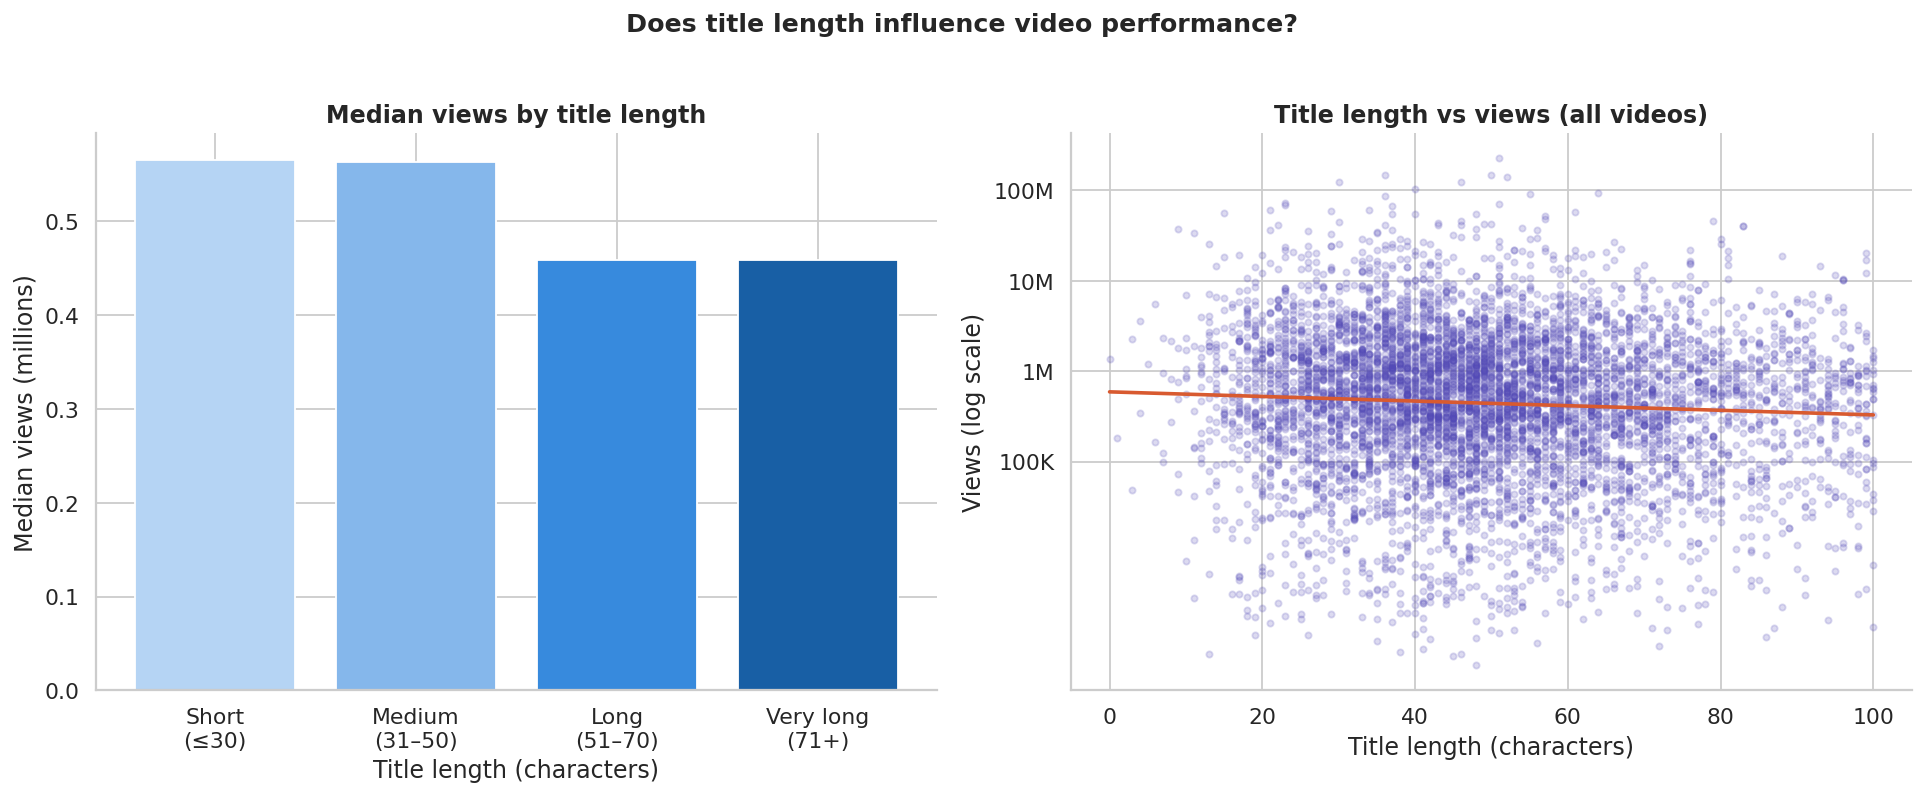


TITLE LENGTH INSIGHTS:
                     median_views  videos
title_length_bucket                      
Short\n(≤30)             565615.0    1094
Medium\n(31–50)          562712.5    2472
Long\n(51–70)            458154.5    1788
Very long\n(71+)         458501.5     996


In [ ]:
# ============================================================
# CELL 6: Does title length affect views?
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bin title lengths into groups
df['title_length_bucket'] = pd.cut(
    df['title_length'],
    bins=[0, 30, 50, 70, 100],
    labels=['Short\n(≤30)', 'Medium\n(31–50)',
            'Long\n(51–70)', 'Very long\n(71+)']
)

bucket_order = ['Short\n(≤30)', 'Medium\n(31–50)',
                'Long\n(51–70)', 'Very long\n(71+)']

# --- Left: median views by title length ---
tl_views = (df.groupby('title_length_bucket', observed=True)['views']
              .median()
              .reindex(bucket_order))

axes[0].bar(tl_views.index, tl_views.values / 1e6,
            color=['#B5D4F4','#85B7EB','#378ADD','#185FA5'],
            edgecolor='white')
axes[0].set_title('Median views by title length', fontweight='bold')
axes[0].set_xlabel('Title length (characters)')
axes[0].set_ylabel('Median views (millions)')

# --- Right: scatter of title length vs views ---
axes[1].scatter(df['title_length'],
                np.log10(df['views'] + 1),
                alpha=0.2, s=12, color='#534AB7')
z2 = np.polyfit(df['title_length'].dropna(),
                np.log10(df.loc[df['title_length'].notna(), 'views'] + 1), 1)
p2 = np.poly1d(z2)
x2 = np.linspace(df['title_length'].min(), df['title_length'].max(), 100)
axes[1].plot(x2, p2(x2), color='#D85A30', linewidth=2)
axes[1].set_xlabel('Title length (characters)')
axes[1].set_ylabel('Views (log scale)')
axes[1].set_title('Title length vs views (all videos)', fontweight='bold')
axes[1].set_yticks([5, 6, 7, 8])
axes[1].set_yticklabels(['100K', '1M', '10M', '100M'])

plt.suptitle('Does title length influence video performance?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_05_title_length.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nTITLE LENGTH INSIGHTS:")
print(df.groupby('title_length_bucket', observed=True)['views']
        .agg(['median','count'])
        .rename(columns={'median':'median_views','count':'videos'})
        .to_string())

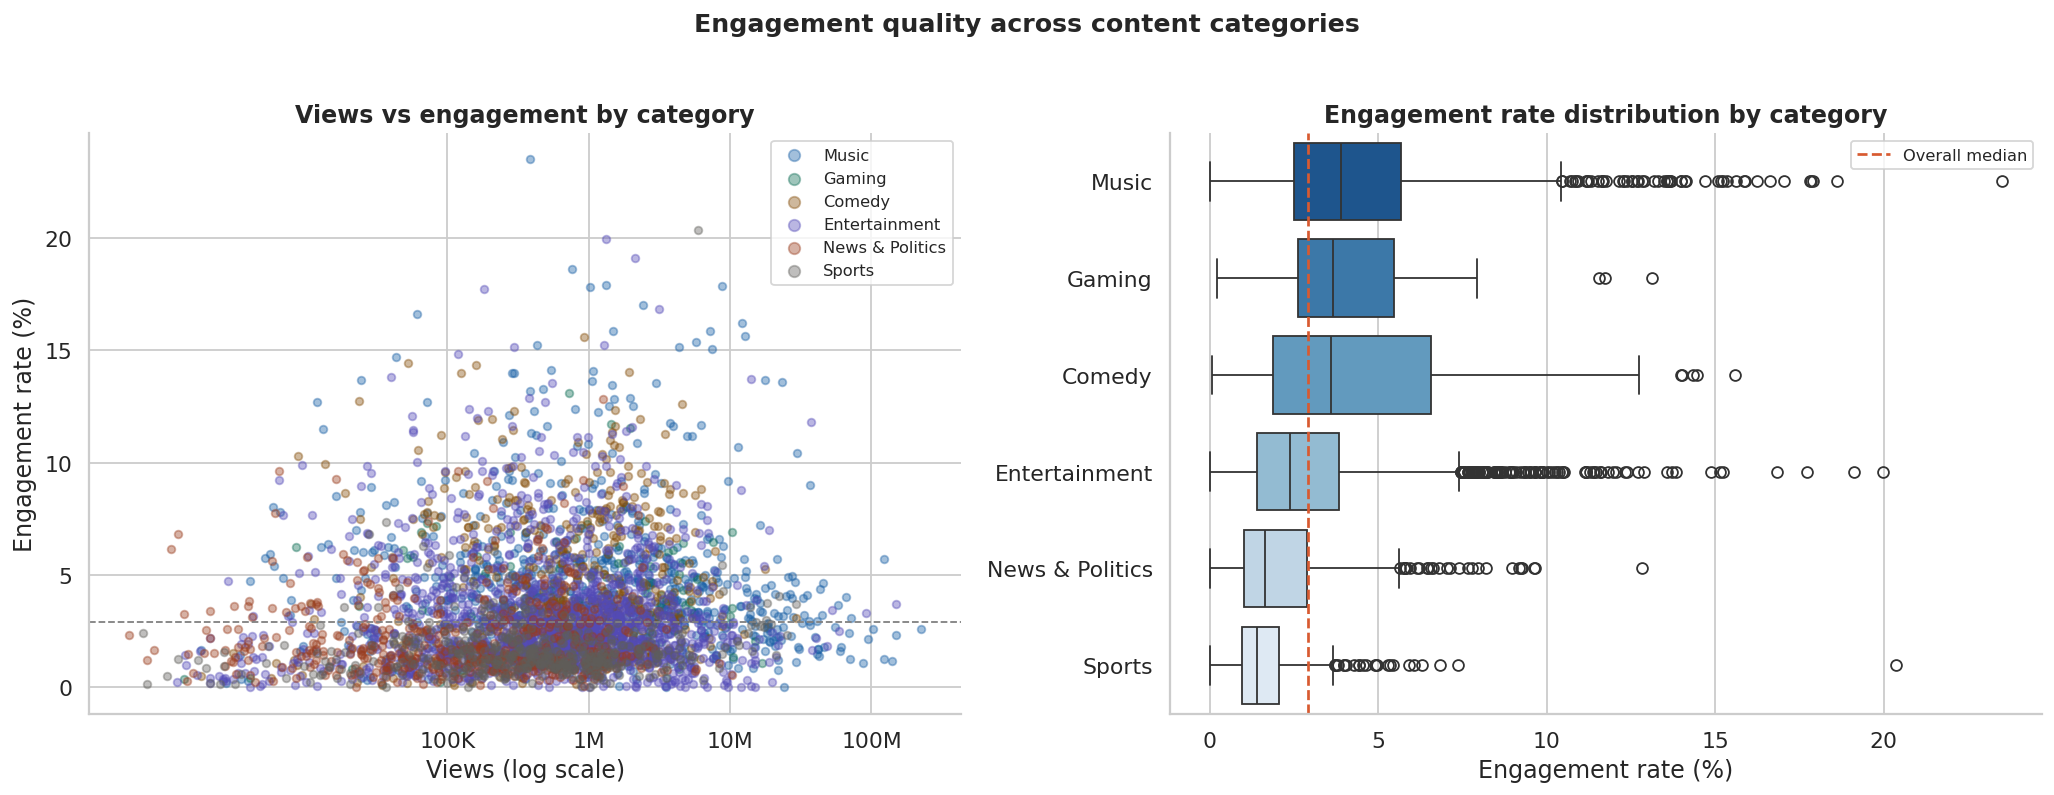

HIGH ENGAGEMENT VIDEOS (above 10%):
  Count: 197 videos (3.1% of dataset)
  Top categories:
category_name
Music             57
Entertainment     36
People & Blogs    29
Comedy            27
Howto & Style     25

LOW ENGAGEMENT VIDEOS (below 1%):
  Count: 824 videos (13.0% of dataset)
  Top categories:
category_name
Entertainment           224
Sports                  124
News & Politics         122
Film & Animation         75
Science & Technology     59


In [ ]:
# ============================================================
# CELL 7: Engagement rate — what drives audience interaction?
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: views vs engagement rate (coloured by category) ---
# Pick top 6 categories for clarity
top_cats = ['Music', 'Gaming', 'Comedy',
            'Entertainment', 'News & Politics', 'Sports']
palette  = ['#185FA5','#0F6E56','#854F0B',
            '#534AB7','#993C1D','#5F5E5A']

for cat, col in zip(top_cats, palette):
    mask = df['category_name'] == cat
    axes[0].scatter(
        np.log10(df.loc[mask, 'views'] + 1),
        df.loc[mask, 'engagement_rate'],
        alpha=0.4, s=18, color=col, label=cat
    )

axes[0].set_xlabel('Views (log scale)')
axes[0].set_ylabel('Engagement rate (%)')
axes[0].set_title('Views vs engagement by category', fontweight='bold')
axes[0].set_xticks([5, 6, 7, 8])
axes[0].set_xticklabels(['100K', '1M', '10M', '100M'])
axes[0].legend(fontsize=9, markerscale=1.5)
axes[0].axhline(y=df['engagement_rate'].median(),
                color='gray', linestyle='--', linewidth=1,
                label='Median engagement')

# --- Right: box plot of engagement rate by top categories ---
df_top = df[df['category_name'].isin(top_cats)].copy()
cat_order = (df_top.groupby('category_name')['engagement_rate']
                   .median()
                   .sort_values(ascending=False)
                   .index.tolist())

sns.boxplot(data=df_top, x='engagement_rate',
            y='category_name', order=cat_order,
            palette='Blues_r', ax=axes[1])
axes[1].set_xlabel('Engagement rate (%)')
axes[1].set_ylabel('')
axes[1].set_title('Engagement rate distribution by category',
                  fontweight='bold')
axes[1].axvline(x=df['engagement_rate'].median(),
                color='#D85A30', linestyle='--',
                linewidth=1.5, label='Overall median')
axes[1].legend(fontsize=9)

plt.suptitle('Engagement quality across content categories',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_06_engagement_deep_dive.png',
            bbox_inches='tight', dpi=150)
plt.show()

# Print high vs low engagement breakdown
print("HIGH ENGAGEMENT VIDEOS (above 10%):")
high_eng = df[df['engagement_rate'] > 10]
print(f"  Count: {len(high_eng)} videos "
      f"({len(high_eng)/len(df)*100:.1f}% of dataset)")
print(f"  Top categories:")
print(high_eng['category_name'].value_counts().head(5).to_string())

print("\nLOW ENGAGEMENT VIDEOS (below 1%):")
low_eng = df[df['engagement_rate'] < 1]
print(f"  Count: {len(low_eng)} videos "
      f"({len(low_eng)/len(df)*100:.1f}% of dataset)")
print(f"  Top categories:")
print(low_eng['category_name'].value_counts().head(5).to_string())

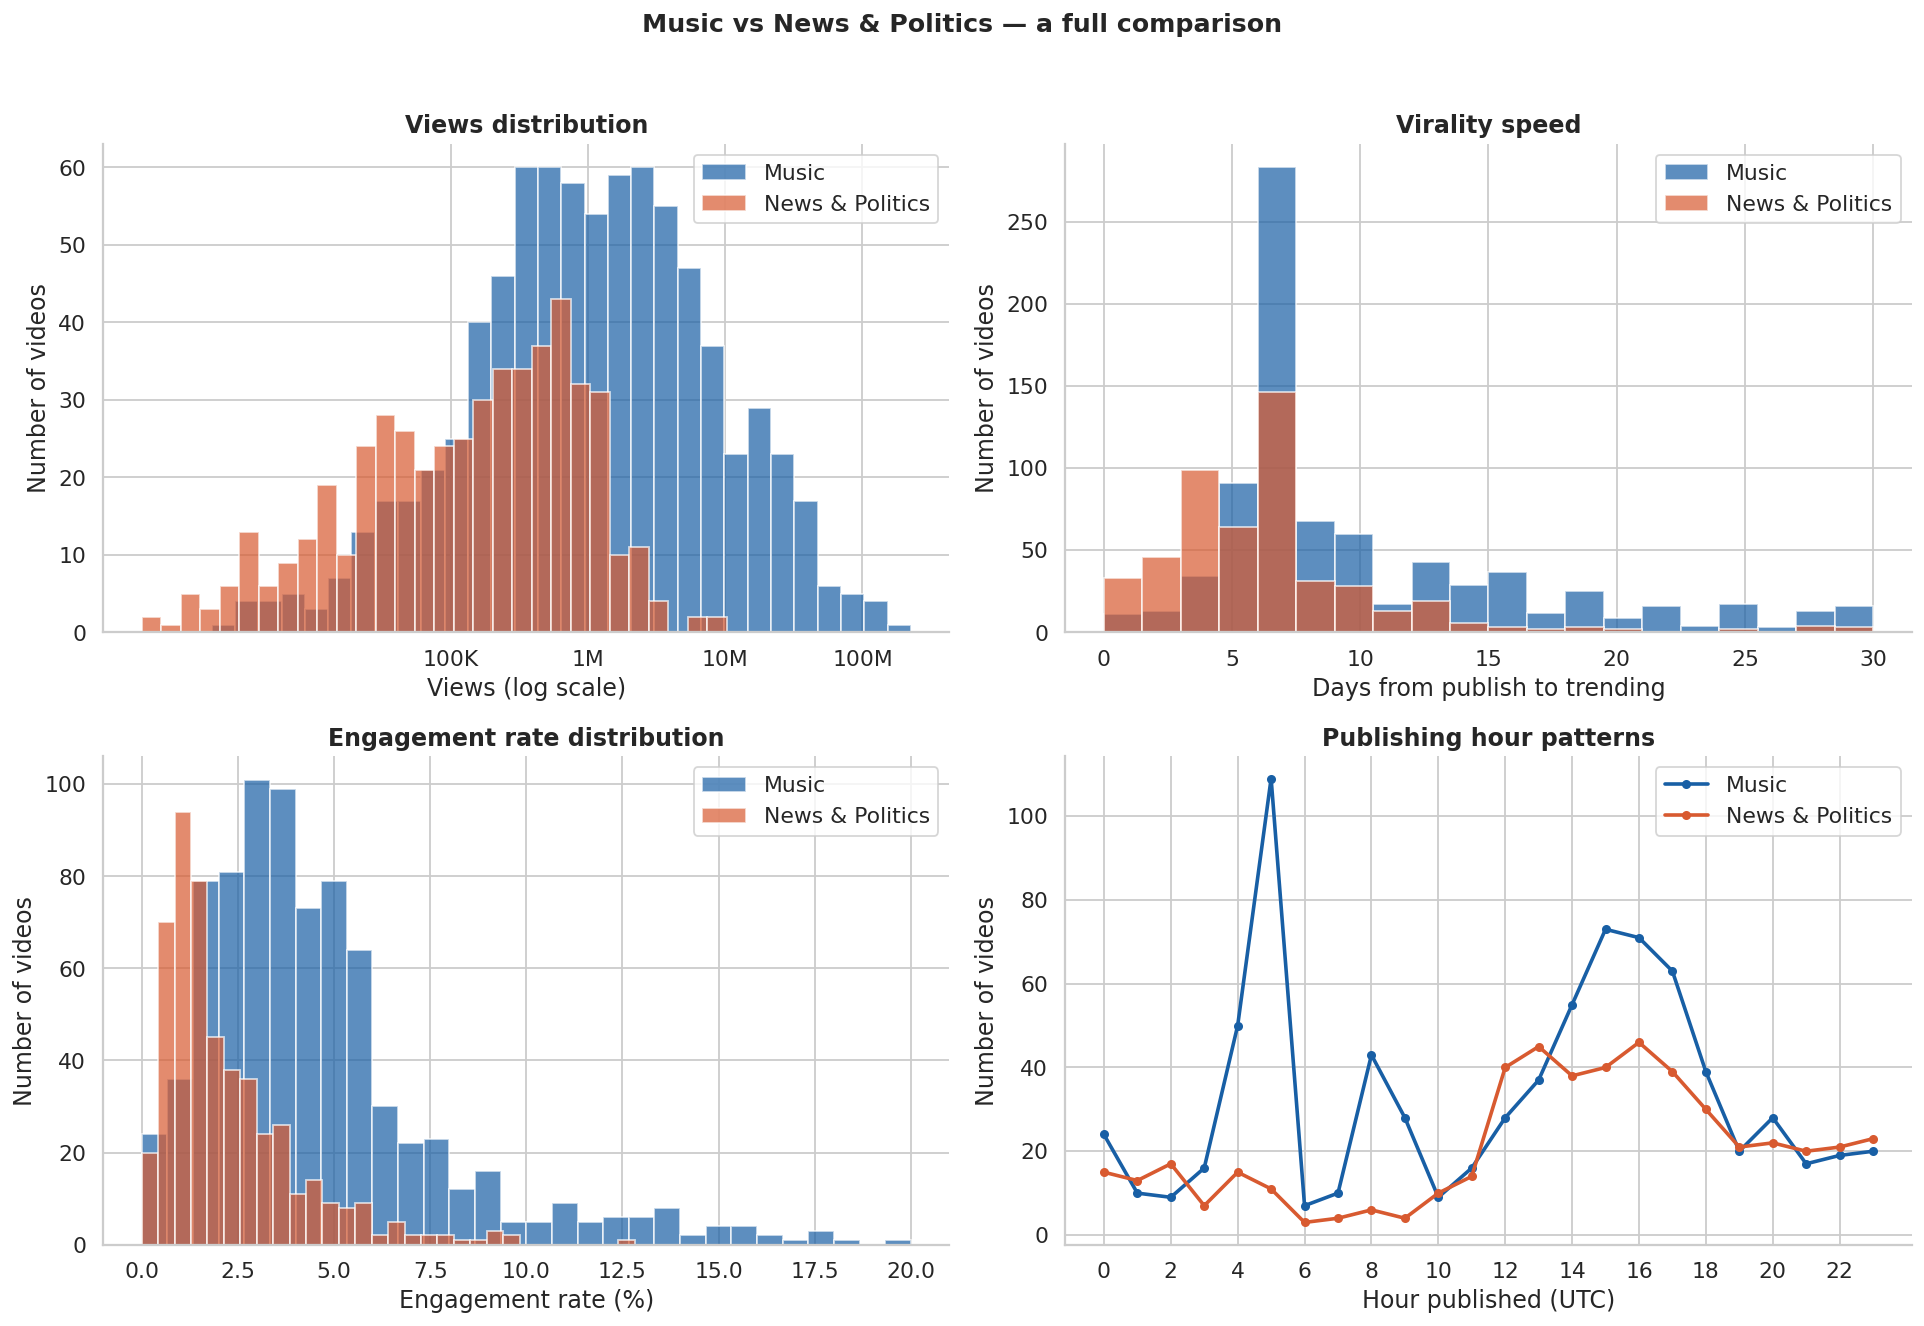

MUSIC vs NEWS & POLITICS — HEAD TO HEAD
  views                  Music=1,096,158.0   News= 178,852.0
  likes                  Music=  39,940.0   News=   1,174.5
  engagement_rate        Music=       3.9   News=       1.6
  days_to_trend          Music=       7.0   News=       6.0
  title_length           Music=      43.0   News=      54.5


In [ ]:
# ============================================================
# CELL 8: News & Politics vs Music — a tale of two categories
# ============================================================

news  = df[df['category_name'] == 'News & Politics']
music = df[df['category_name'] == 'Music']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# --- Top left: views distribution comparison ---
axes[0,0].hist(np.log10(music['views']+1), bins=30,
               alpha=0.7, color='#185FA5', label='Music')
axes[0,0].hist(np.log10(news['views']+1),  bins=30,
               alpha=0.7, color='#D85A30', label='News & Politics')
axes[0,0].set_xlabel('Views (log scale)')
axes[0,0].set_ylabel('Number of videos')
axes[0,0].set_title('Views distribution', fontweight='bold')
axes[0,0].set_xticks([5,6,7,8])
axes[0,0].set_xticklabels(['100K','1M','10M','100M'])
axes[0,0].legend()

# --- Top right: days to trend comparison ---
axes[0,1].hist(music['days_to_trend'].clip(0,30), bins=20,
               alpha=0.7, color='#185FA5', label='Music')
axes[0,1].hist(news['days_to_trend'].clip(0,30),  bins=20,
               alpha=0.7, color='#D85A30', label='News & Politics')
axes[0,1].set_xlabel('Days from publish to trending')
axes[0,1].set_ylabel('Number of videos')
axes[0,1].set_title('Virality speed', fontweight='bold')
axes[0,1].legend()

# --- Bottom left: engagement rate comparison ---
axes[1,0].hist(music['engagement_rate'].clip(0,20), bins=30,
               alpha=0.7, color='#185FA5', label='Music')
axes[1,0].hist(news['engagement_rate'].clip(0,20),  bins=30,
               alpha=0.7, color='#D85A30', label='News & Politics')
axes[1,0].set_xlabel('Engagement rate (%)')
axes[1,0].set_ylabel('Number of videos')
axes[1,0].set_title('Engagement rate distribution', fontweight='bold')
axes[1,0].legend()

# --- Bottom right: publish hour comparison ---
music_hours = music['publish_hour'].value_counts().sort_index()
news_hours  = news['publish_hour'].value_counts().sort_index()
axes[1,1].plot(music_hours.index, music_hours.values,
               color='#185FA5', linewidth=2,
               marker='o', markersize=4, label='Music')
axes[1,1].plot(news_hours.index,  news_hours.values,
               color='#D85A30', linewidth=2,
               marker='o', markersize=4, label='News & Politics')
axes[1,1].set_xlabel('Hour published (UTC)')
axes[1,1].set_ylabel('Number of videos')
axes[1,1].set_title('Publishing hour patterns', fontweight='bold')
axes[1,1].set_xticks(range(0,24,2))
axes[1,1].legend()

plt.suptitle('Music vs News & Politics — a full comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_07_music_vs_news.png',
            bbox_inches='tight', dpi=150)
plt.show()

# Summary stats comparison
print("MUSIC vs NEWS & POLITICS — HEAD TO HEAD")
print("=" * 52)
metrics = ['views','likes','engagement_rate',
           'days_to_trend','title_length']
for m in metrics:
    mv = music[m].median()
    nv = news[m].median()
    print(f"  {m:<22} Music={mv:>10,.1f}   "
          f"News={nv:>10,.1f}")

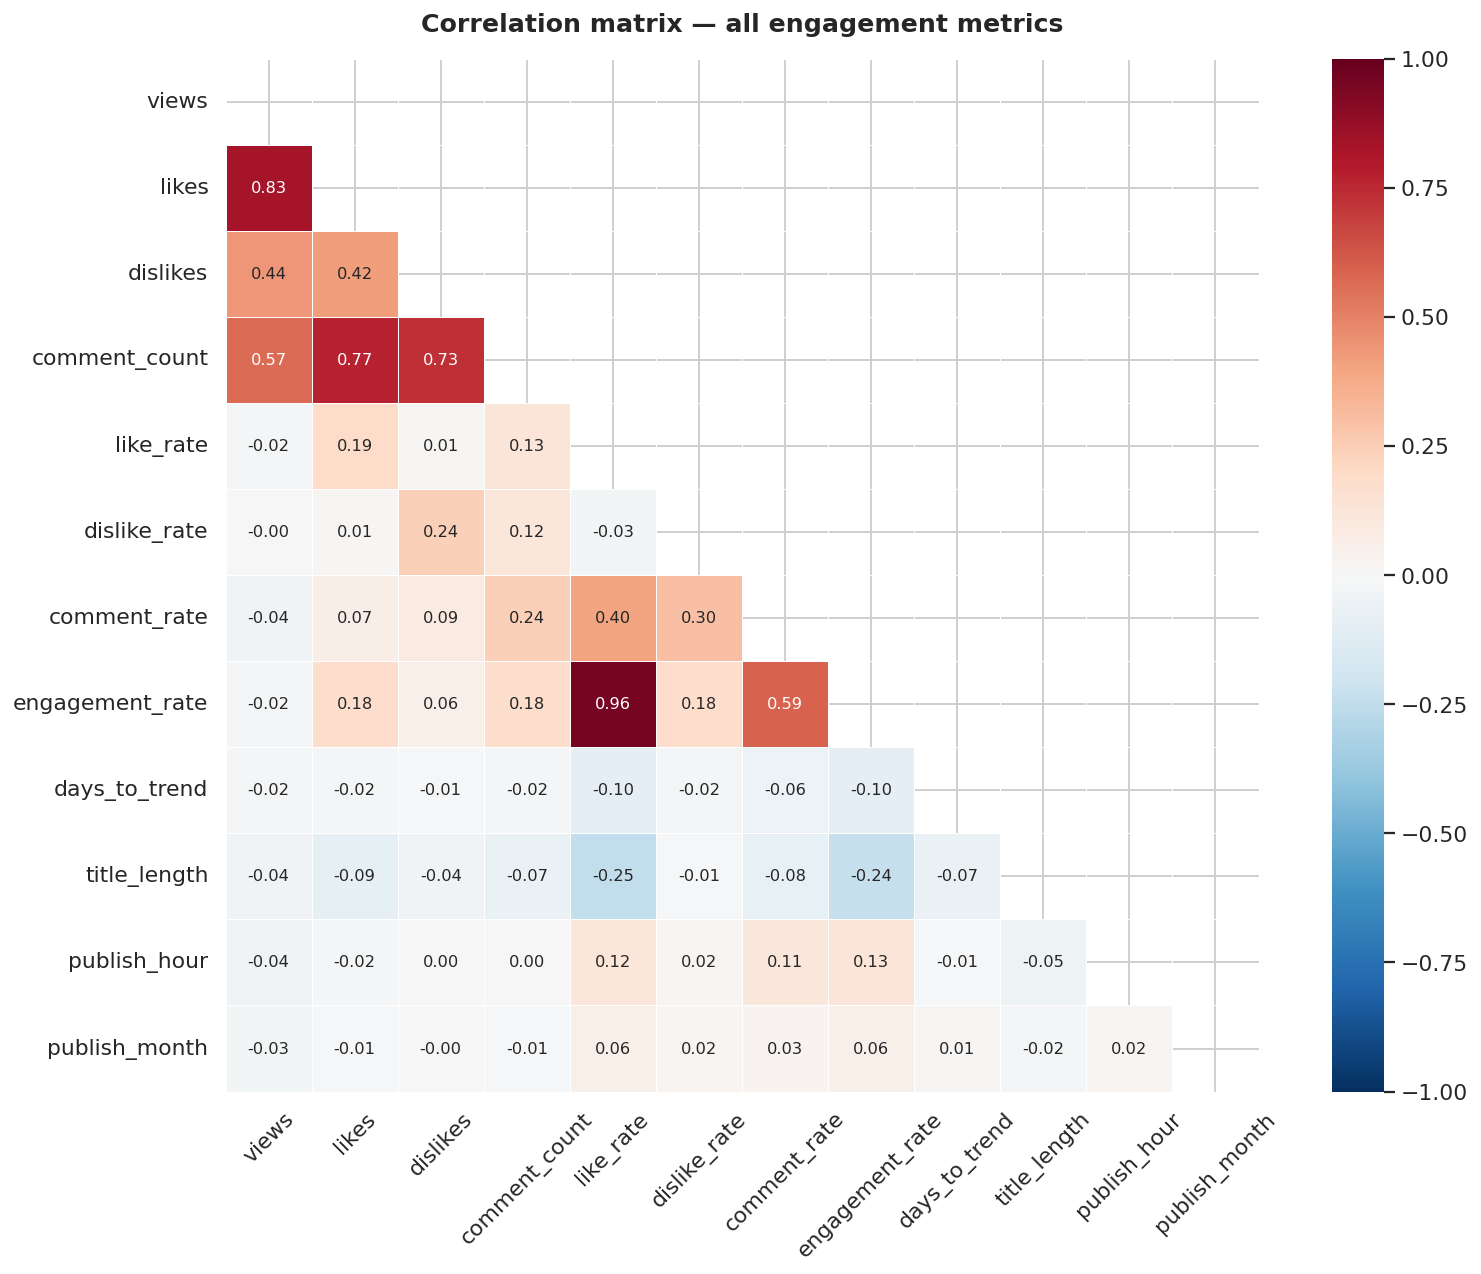

STRONGEST CORRELATIONS WITH VIEWS:
  likes                  r=  0.83  (strong positive)
  comment_count          r=  0.57  (moderate positive)
  dislikes               r=  0.44  (moderate positive)
  comment_rate           r= -0.04  (weak negative)
  title_length           r= -0.04  (weak negative)
  publish_hour           r= -0.04  (weak negative)
  publish_month          r= -0.03  (weak negative)
  like_rate              r= -0.02  (weak negative)
  engagement_rate        r= -0.02  (weak negative)
  days_to_trend          r= -0.02  (weak negative)
  dislike_rate           r= -0.00  (weak negative)


In [ ]:
# ============================================================
# CELL 9: Correlation heatmap — how all metrics relate
# ============================================================

# Select numeric columns that matter for analysis
corr_cols = ['views', 'likes', 'dislikes', 'comment_count',
             'like_rate', 'dislike_rate', 'comment_rate',
             'engagement_rate', 'days_to_trend',
             'title_length', 'publish_hour', 'publish_month']

corr_matrix = df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(13, 10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 9}
)

ax.set_title('Correlation matrix — all engagement metrics',
             fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('plot_08_correlation_heatmap.png',
            bbox_inches='tight', dpi=150)
plt.show()

# Print the strongest relationships
print("STRONGEST CORRELATIONS WITH VIEWS:")
views_corr = corr_matrix['views'].drop('views').sort_values(
    key=abs, ascending=False)
for col, val in views_corr.items():
    direction = "positive" if val > 0 else "negative"
    strength  = ("strong" if abs(val) > 0.6
                 else "moderate" if abs(val) > 0.3
                 else "weak")
    print(f"  {col:<22} r={val:>6.2f}  "
          f"({strength} {direction})")